<a href="https://colab.research.google.com/github/mathiyarasi05/Cardio/blob/main/Fusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

import pandas as pd

# Change filename if needed
file_path = "/content/drive/MyDrive/fusion/fusion_data.xlsx"

df = pd.read_excel(file_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (900, 67)


,ECG_f1,ECG_f2,ECG_f3,ECG_f4,ECG_f5,ECG_f6,ECG_f7,ECG_f8,ECG_f9,ECG_f10,...,ECG_f58,ECG_f59,ECG_f60,ECG_f61,ECG_f62,ECG_f63,ECG_f64,EDV,ESV,EF
0,0.2449,-0.2115,0.1082,-0.5356,0.2377,-0.2609,-0.0956,0.4501,-0.2331,0.6255,...,0.4800,0.7255,0.9353,0.4620,0.7442,-0.3221,-0.0637,144.80,101.69,29.77
1,-0.1478,-0.9472,-0.7631,-0.2816,-0.8394,0.9876,0.9501,-0.1098,-0.8313,-0.2880,...,0.8891,0.4160,0.6354,0.0344,-0.6875,0.9423,0.2003,143.71,90.33,37.14
2,-0.2120,-0.3475,0.0981,0.0931,0.7584,-0.0511,0.4850,0.6652,-0.1826,-0.5936,...,-0.8686,0.2039,0.6104,0.4111,-0.7724,-0.5350,-0.5117,176.00,108.05,38.61
3,-0.3450,-0.1204,0.6447,-0.7295,0.9280,-0.2210,0.3715,-0.0346,0.4921,0.3643,...,-0.8491,-0.9609,-0.4223,-0.4551,-0.2505,0.7471,-0.9290,142.08,112.82,20.59
4,0.7035,-0.1912,0.6557,-0.3881,-0.5233,-0.4605,0.2661,-0.1287,0.7519,-0.8447,...,0.3599,-0.0168,-0.8170,0.3532,0.0665,0.8519,0.0208,105.14,54.72,47.96


In [ ]:
print(df.columns)

Index(['ECG_f1', 'ECG_f2', 'ECG_f3', 'ECG_f4', 'ECG_f5', 'ECG_f6', 'ECG_f7',
       'ECG_f8', 'ECG_f9', 'ECG_f10', 'ECG_f11', 'ECG_f12', 'ECG_f13',
       'ECG_f14', 'ECG_f15', 'ECG_f16', 'ECG_f17', 'ECG_f18', 'ECG_f19',
       'ECG_f20', 'ECG_f21', 'ECG_f22', 'ECG_f23', 'ECG_f24', 'ECG_f25',
       'ECG_f26', 'ECG_f27', 'ECG_f28', 'ECG_f29', 'ECG_f30', 'ECG_f31',
       'ECG_f32', 'ECG_f33', 'ECG_f34', 'ECG_f35', 'ECG_f36', 'ECG_f37',
       'ECG_f38', 'ECG_f39', 'ECG_f40', 'ECG_f41', 'ECG_f42', 'ECG_f43',
       'ECG_f44', 'ECG_f45', 'ECG_f46', 'ECG_f47', 'ECG_f48', 'ECG_f49',
       'ECG_f50', 'ECG_f51', 'ECG_f52', 'ECG_f53', 'ECG_f54', 'ECG_f55',
       'ECG_f56', 'ECG_f57', 'ECG_f58', 'ECG_f59', 'ECG_f60', 'ECG_f61',
       'ECG_f62', 'ECG_f63', 'ECG_f64', 'EDV', 'ESV', 'EF'],
      dtype='object')


In [ ]:

import numpy as np

df["Label"] = np.random.randint(0, 5, size=len(df))

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Label', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
from sklearn.model_selection import train_test_split

y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.24444444444444444

Classification Report:
              precision    recall  f1-score   support

           0       0.23      0.41      0.29        29
           1       0.13      0.15      0.14        40
           2       0.30      0.38      0.34        37
           3       0.33      0.10      0.15        30
           4       0.35      0.20      0.26        44

    accuracy                           0.24       180
   macro avg       0.27      0.25      0.24       180
weighted avg       0.27      0.24      0.24       180


Confusion Matrix:
[[12  9  4  0  4]
 [13  6 10  4  7]
 [ 8 11 14  1  3]
 [ 8  9  7  3  3]
 [12 11 11  1  9]]


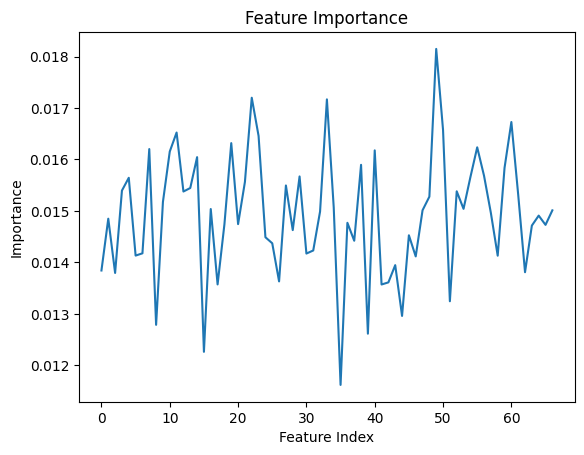

In [ ]:

import matplotlib.pyplot as plt

importances = model.feature_importances_

plt.plot(importances)
plt.title("Feature Importance")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.show()